<a href="https://colab.research.google.com/github/payal-web/IPL-Match-Analytics-Prediction-System/blob/main/ipl_match_winner_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — Install dependencies
!pip install pyspark flask pyngrok plotly scikit-learn pandas matplotlib seaborn --quiet

In [ ]:
# CELL 3 — Upload files (run this in Colab)
from google.colab import files

print("Upload matches.csv and deliveries.csv")
uploaded = files.upload()

Upload matches.csv and deliveries.csv


Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv


In [ ]:
# CELL 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import pickle
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# CELL 4 — Load datasets
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("MATCHES shape:", matches.shape)
print("DELIVERIES shape:", deliveries.shape)
print("\nMatches columns:", list(matches.columns))
print("\nDeliveries columns:", list(deliveries.columns))

matches.head(3)

MATCHES shape: (1095, 20)
DELIVERIES shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [ ]:
# CELL 5 — Clean data
# Fill missing values
matches['city'].fillna('Unknown', inplace=True)
matches['winner'].fillna('No Result', inplace=True)
matches['player_of_match'].fillna('Unknown', inplace=True)
matches['result_margin'].fillna(0, inplace=True)
matches['method'].fillna('Normal', inplace=True)

# Fix team names — some teams changed names over the years
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings',
    'Pune Warriors': 'Pune Warriors India'
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_name_map)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_map)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_map)

# Remove super over rows from deliveries
deliveries = deliveries[deliveries['inning'] <= 2]

print("✅ Data cleaned!")
print(f"Matches: {matches.shape[0]} rows")
print(f"Deliveries: {deliveries.shape[0]} rows")

✅ Data cleaned!
Matches: 1095 rows
Deliveries: 260759 rows


In [ ]:
# CELL 6 — Feature Engineering

# Add cumulative runs per match per over (for ball-by-ball chart)
deliveries['cumulative_runs'] = deliveries.groupby(['match_id', 'inning'])['total_runs'].cumsum()

# Total runs per team per match
match_scores = deliveries.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()
match_scores.columns = ['match_id', 'inning', 'batting_team', 'total_score']

# Runs per over
runs_per_over = deliveries.groupby(['match_id', 'inning', 'over'])['total_runs'].sum().reset_index()

# Wickets per over
wickets_per_over = deliveries.groupby(['match_id', 'inning', 'over'])['is_wicket'].sum().reset_index()

print("✅ Feature engineering done!")
print(match_scores.head())

✅ Feature engineering done!
   match_id  inning                 batting_team  total_score
0    335982       1        Kolkata Knight Riders          222
1    335982       2  Royal Challengers Bangalore           82
2    335983       1          Chennai Super Kings          240
3    335983       2                 Punjab Kings          207
4    335984       1             Rajasthan Royals          129


In [ ]:
# CELL 7 — PySpark Processing
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Create Spark session
spark = SparkSession.builder \
    .appName("IPL Analytics") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Convert pandas → Spark DataFrames
spark_matches = spark.createDataFrame(matches)
spark_deliveries = spark.createDataFrame(deliveries)

print("✅ Spark DataFrames created!")
print("Matches count:", spark_matches.count())
print("Deliveries count:", spark_deliveries.count())

✅ Spark DataFrames created!
Matches count: 1095
Deliveries count: 260759


In [ ]:
# CELL 8 — Spark Aggregations

# 1. Total runs per match
total_runs_per_match = spark_deliveries.groupBy("match_id", "batting_team") \
    .agg(F.sum("total_runs").alias("total_runs")) \
    .orderBy("match_id")

print("=== Total Runs Per Match (Top 10) ===")
total_runs_per_match.show(10)

# 2. Runs per over per match
runs_per_over_spark = spark_deliveries.groupBy("match_id", "inning", "over") \
    .agg(F.sum("total_runs").alias("runs_in_over")) \
    .orderBy("match_id", "inning", "over")

print("=== Runs Per Over (Top 10) ===")
runs_per_over_spark.show(10)

# 3. Team performance — wins
team_wins = spark_matches.filter(F.col("winner") != "No Result") \
    .groupBy("winner") \
    .agg(F.count("*").alias("wins")) \
    .orderBy(F.desc("wins"))

print("=== Team Wins ===")
team_wins.show(20)

# Save results back to pandas for later use
team_wins_df = team_wins.toPandas()

=== Total Runs Per Match (Top 10) ===
+--------+--------------------+----------+
|match_id|        batting_team|total_runs|
+--------+--------------------+----------+
|  335982|Kolkata Knight Ri...|       222|
|  335982|Royal Challengers...|        82|
|  335983| Chennai Super Kings|       240|
|  335983|        Punjab Kings|       207|
|  335984|    Rajasthan Royals|       129|
|  335984|      Delhi Capitals|       132|
|  335985|Royal Challengers...|       166|
|  335985|      Mumbai Indians|       165|
|  335986|Kolkata Knight Ri...|       112|
|  335986| Sunrisers Hyderabad|       110|
+--------+--------------------+----------+
only showing top 10 rows
=== Runs Per Over (Top 10) ===
+--------+------+----+------------+
|match_id|inning|over|runs_in_over|
+--------+------+----+------------+
|  335982|     1|   0|           3|
|  335982|     1|   1|          18|
|  335982|     1|   2|           6|
|  335982|     1|   3|          23|
|  335982|     1|   4|          10|
|  335982|     1

In [ ]:
# CELL 9 — Store data in SQLite

conn = sqlite3.connect('ipl.db')

# Store tables
matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)

print("✅ Data stored in SQLite!")

# --- SQL Query 1: Win percentage per team ---
win_pct_query = """
SELECT
    team,
    wins,
    total_matches,
    ROUND(wins * 100.0 / total_matches, 1) AS win_percentage
FROM (
    SELECT
        team1 AS team,
        COUNT(*) AS total_matches,
        SUM(CASE WHEN winner = team1 THEN 1 ELSE 0 END) AS wins
    FROM matches
    WHERE winner != 'No Result'
    GROUP BY team1
)
ORDER BY win_percentage DESC
"""
win_pct_df = pd.read_sql_query(win_pct_query, conn)
print("\n=== Win % Per Team ===")
print(win_pct_df.head(10))

# --- SQL Query 2: Venue stats ---
venue_query = """
SELECT venue, city, COUNT(*) as matches_played
FROM matches
GROUP BY venue
ORDER BY matches_played DESC
LIMIT 10
"""
venue_df = pd.read_sql_query(venue_query, conn)
print("\n=== Top Venues ===")
print(venue_df)

# --- SQL Query 3: Toss impact ---
toss_query = """
SELECT
    toss_decision,
    COUNT(*) as total,
    SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) as toss_then_won,
    ROUND(SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS toss_win_pct
FROM matches
WHERE winner != 'No Result'
GROUP BY toss_decision
"""
toss_df = pd.read_sql_query(toss_query, conn)
print("\n=== Toss Impact ===")
print(toss_df)

conn.close()

✅ Data stored in SQLite!

=== Win % Per Team ===
                          team  wins  total_matches  win_percentage
0         Lucknow Super Giants    16             22            72.7
1          Chennai Super Kings    75            128            58.6
2               Mumbai Indians    70            123            56.9
3             Rajasthan Royals    55            101            54.5
4        Kolkata Knight Riders    65            121            53.7
5               Gujarat Titans    11             21            52.4
6      Rising Pune Supergiants     7             14            50.0
7  Royal Challengers Bangalore    66            132            50.0
8               Delhi Capitals    61            125            48.8
9          Sunrisers Hyderabad    57            125            45.6

=== Top Venues ===
                                        venue        city  matches_played
0                                Eden Gardens     Kolkata              77
1                            Wankhe

In [ ]:
# CELL 10 — Train ML Model

# Step 1: Build training data
# For each match, we create a training sample
# Features: team1, team2, venue, innings score, overs, wickets, target
# Target: winner

conn = sqlite3.connect('ipl.db')

# Get first innings scores
first_innings = pd.read_sql_query("""
    SELECT match_id, batting_team,
           SUM(total_runs) as score,
           COUNT(DISTINCT over) as overs_played,
           SUM(is_wicket) as wickets
    FROM deliveries
    WHERE inning = 1
    GROUP BY match_id, batting_team
""", conn)

# Merge with matches
ml_data = matches.merge(first_innings,
                         left_on=['id', 'team1'],
                         right_on=['match_id', 'batting_team'],
                         how='inner')

# Keep only needed columns
ml_data = ml_data[['team1','team2','venue','score','overs_played','wickets','target_runs','winner']].copy()
ml_data = ml_data[ml_data['winner'] != 'No Result'].copy()
ml_data.dropna(inplace=True)

print("Training samples:", len(ml_data))
print(ml_data.head(3))
conn.close()

Training samples: 791
                 team1                        team2  \
0       Mumbai Indians  Royal Challengers Bangalore   
1  Sunrisers Hyderabad               Delhi Capitals   
2  Chennai Super Kings               Mumbai Indians   

                                       venue  score  overs_played  wickets  \
0                           Wankhede Stadium    165            20        7   
1  Rajiv Gandhi International Stadium, Uppal    142            20        8   
2            MA Chidambaram Stadium, Chepauk    208            20        5   

   target_runs                       winner  
0        166.0  Royal Challengers Bangalore  
1        143.0               Delhi Capitals  
2        209.0          Chennai Super Kings  


In [ ]:
# CELL 11 — Encode + Train

# Label encoders for each categorical column
le_team = LabelEncoder()
le_venue = LabelEncoder()
le_winner = LabelEncoder()

# Fit on all possible team names
all_teams = list(set(list(ml_data['team1']) + list(ml_data['team2']) + list(ml_data['winner'])))
all_venues = list(ml_data['venue'].unique())

le_team.fit(all_teams)
le_venue.fit(all_venues)
le_winner.fit(all_teams)

# Encode
ml_data['team1_enc'] = le_team.transform(ml_data['team1'])
ml_data['team2_enc'] = le_team.transform(ml_data['team2'])
ml_data['venue_enc'] = le_venue.transform(ml_data['venue'])
ml_data['winner_enc'] = le_winner.transform(ml_data['winner'])

# Features (X) and Target (y)
feature_cols = ['team1_enc', 'team2_enc', 'venue_enc', 'score', 'overs_played', 'wickets', 'target_runs']
X = ml_data[feature_cols]
y = ml_data['winner_enc']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model trained! Accuracy: {acc*100:.1f}%")

# Save model + encoders using pickle
with open('ipl_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'le_team': le_team,
        'le_venue': le_venue,
        'le_winner': le_winner,
        'feature_cols': feature_cols
    }, f)

print("✅ Model saved as ipl_model.pkl")

✅ Model trained! Accuracy: 47.2%
✅ Model saved as ipl_model.pkl


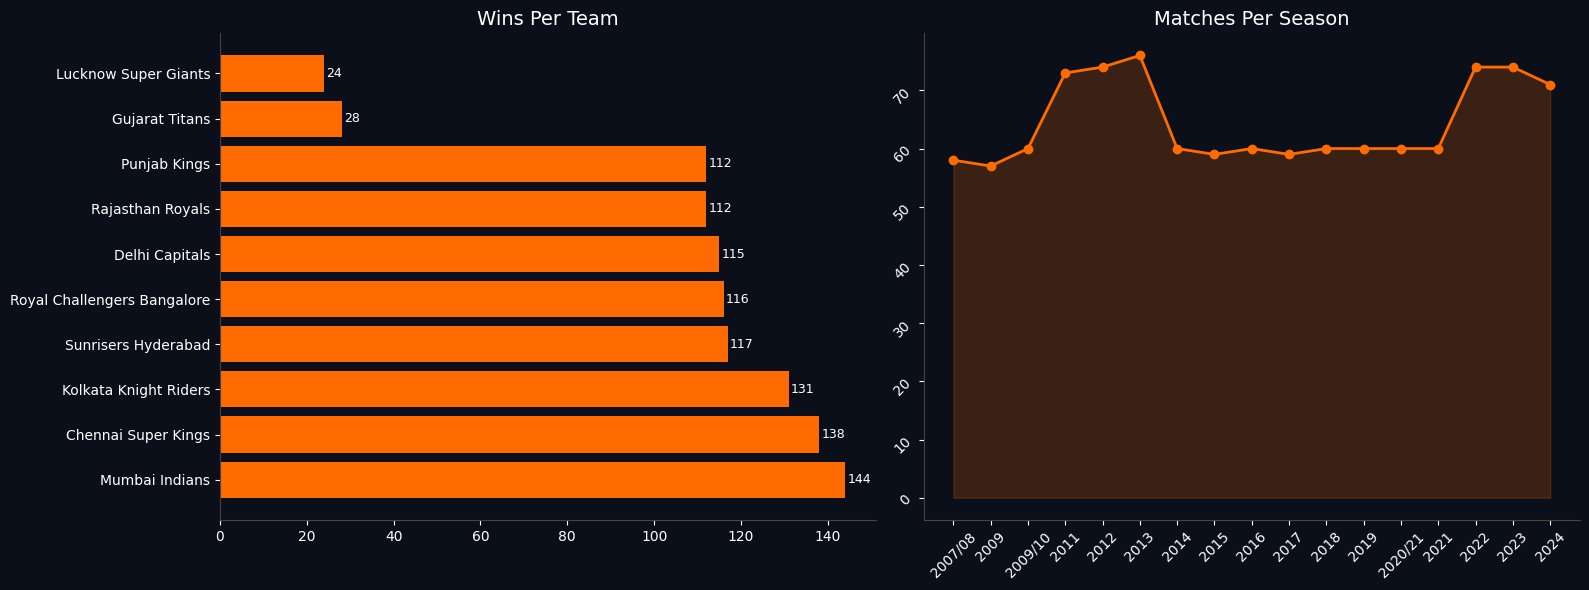

✅ Static charts saved!


In [ ]:
# CELL 12 — Static Charts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0b0f1a')

# Chart 1: Wins per team
wins_data = matches[matches['winner'] != 'No Result']['winner'].value_counts().head(10)
axes[0].set_facecolor('#0b0f1a')
bars = axes[0].barh(wins_data.index, wins_data.values, color='#ff6b00')
axes[0].set_title('Wins Per Team', color='white', fontsize=14)
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('#444')
axes[0].spines['left'].set_color('#444')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar in bars:
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va='center', color='white', fontsize=9)

# Chart 2: Matches per season
season_counts = matches['season'].value_counts().sort_index()
axes[1].set_facecolor('#0b0f1a')
axes[1].plot(season_counts.index.astype(str), season_counts.values,
             color='#ff6b00', marker='o', linewidth=2)
axes[1].fill_between(range(len(season_counts)), season_counts.values, alpha=0.2, color='#ff6b00')
axes[1].set_title('Matches Per Season', color='white', fontsize=14)
axes[1].tick_params(colors='white', rotation=45)
axes[1].spines['bottom'].set_color('#444')
axes[1].spines['left'].set_color('#444')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('static_charts.png', dpi=100, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()
print("✅ Static charts saved!")

In [ ]:
# CELL 13 — Interactive Charts

# 1. Ball-by-ball run progression for a sample match
sample_match_id = matches['id'].iloc[0]
sample_del = deliveries[deliveries['match_id'] == sample_match_id].copy()

# Get team names
t1 = sample_del[sample_del['inning']==1]['batting_team'].iloc[0]
t2 = sample_del[sample_del['inning']==2]['batting_team'].iloc[0]

inn1 = sample_del[sample_del['inning']==1].copy()
inn2 = sample_del[sample_del['inning']==2].copy()
inn1['ball_num'] = range(1, len(inn1)+1)
inn2['ball_num'] = range(1, len(inn2)+1)
inn1['cum_runs'] = inn1['total_runs'].cumsum()
inn2['cum_runs'] = inn2['total_runs'].cumsum()

fig_ball = go.Figure()
fig_ball.add_trace(go.Scatter(x=inn1['ball_num'], y=inn1['cum_runs'],
                               name=t1, line=dict(color='#ff6b00', width=2)))
fig_ball.add_trace(go.Scatter(x=inn2['ball_num'], y=inn2['cum_runs'],
                               name=t2, line=dict(color='#00aaff', width=2)))
fig_ball.update_layout(
    title=f'Ball-by-Ball Run Progression — Match {sample_match_id}',
    xaxis_title='Ball Number', yaxis_title='Cumulative Runs',
    paper_bgcolor='#0b0f1a', plot_bgcolor='#0b0f1a',
    font=dict(color='white'), legend=dict(bgcolor='#1a1f2e')
)
fig_ball.show()

# 2. Toss Decision Distribution (Pie)
toss_counts = matches['toss_decision'].value_counts()
fig_toss = px.pie(values=toss_counts.values, names=toss_counts.index,
                   title='Toss Decision Distribution',
                   color_discrete_sequence=['#ff6b00', '#4a90d9'])
fig_toss.update_layout(paper_bgcolor='#0b0f1a', font=dict(color='white'))
fig_toss.show()

# 3. Win Probability (sample — placeholder for flask app)
fig_wp = go.Figure()
fig_wp.add_trace(go.Bar(x=['Team A', 'Team B'], y=[65, 35],
                         marker_color=['#ff6b00', '#4a90d9']))
fig_wp.update_layout(title='Win Probability',
                      paper_bgcolor='#0b0f1a', plot_bgcolor='#0b0f1a',
                      font=dict(color='white'))
fig_wp.show()

print("✅ Interactive charts done!")

✅ Interactive charts done!


In [ ]:
# CELL 14 — Write Flask app.py

flask_code = '''
import os, json, pickle, sqlite3
import pandas as pd
import numpy as np
from flask import Flask, render_template, request, jsonify
import plotly
import plotly.graph_objects as go
import plotly.express as px

app = Flask(__name__)

# Load model
with open("ipl_model.pkl", "rb") as f:
    bundle = pickle.load(f)

model     = bundle["model"]
le_team   = bundle["le_team"]
le_venue  = bundle["le_venue"]
le_winner = bundle["le_winner"]

matches    = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Clean team names
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Kings XI Punjab": "Punjab Kings"
}
for col in ["team1","team2","winner","toss_winner"]:
    matches[col] = matches[col].replace(team_name_map)
deliveries["batting_team"]  = deliveries["batting_team"].replace(team_name_map)
deliveries["bowling_team"]  = deliveries["bowling_team"].replace(team_name_map)
deliveries = deliveries[deliveries["inning"] <= 2]

teams   = sorted(matches["team1"].unique().tolist())
venues  = sorted(matches["venue"].unique().tolist())
batsmen = sorted(deliveries["batter"].unique().tolist())
bowlers = sorted(deliveries["bowler"].unique().tolist())

def safe_encode(le, value, fallback_idx=0):
    """Handle unseen labels gracefully"""
    if value in le.classes_:
        return le.transform([value])[0]
    return fallback_idx


@app.route("/")
def home():
    return render_template("home.html",
                           total_matches=len(matches),
                           total_teams=len(teams),
                           total_seasons=matches["season"].nunique())


@app.route("/predict", methods=["GET","POST"])
def predict():
    prediction = None
    prob_team1 = 0
    prob_team2 = 0
    if request.method == "POST":
        team1   = request.form.get("team1", teams[0])
        team2   = request.form.get("team2", teams[1])
        venue   = request.form.get("venue", venues[0])
        score   = float(request.form.get("score", 0))
        overs   = float(request.form.get("overs", 0))
        wickets = float(request.form.get("wickets", 0))
        target  = float(request.form.get("target", 150))

        t1_enc  = safe_encode(le_team, team1)
        t2_enc  = safe_encode(le_team, team2)
        v_enc   = safe_encode(le_venue, venue)

        X = [[t1_enc, t2_enc, v_enc, score, overs, wickets, target]]
        proba = model.predict_proba(X)[0]

        # Get probabilities for team1 and team2
        classes = list(le_winner.classes_)
        t1_prob = proba[le_winner.transform([team1])[0]] if team1 in classes else 0.5
        t2_prob = proba[le_winner.transform([team2])[0]] if team2 in classes else 0.5
        total   = t1_prob + t2_prob
        if total > 0:
            t1_prob = round(t1_prob / total * 100, 1)
            t2_prob = round(100 - t1_prob, 1)
        else:
            t1_prob, t2_prob = 50.0, 50.0

        winner_enc = model.predict(X)[0]
        prediction = le_winner.inverse_transform([winner_enc])[0]
        prob_team1 = t1_prob if prediction == team1 else t2_prob
        prob_team2 = 100 - prob_team1

    return render_template("predict.html",
                           teams=teams, venues=venues,
                           batsmen=batsmen[:200], bowlers=bowlers[:200],
                           prediction=prediction,
                           prob_team1=prob_team1,
                           prob_team2=prob_team2,
                           selected_team1=request.form.get("team1",""),
                           selected_team2=request.form.get("team2",""))


@app.route("/analytics")
def analytics():
    # 1. Wins per team bar chart
    wins = matches[matches["winner"] != "No Result"]["winner"].value_counts().head(10)
    fig1 = go.Figure(go.Bar(y=wins.index.tolist(), x=wins.values.tolist(),
                             orientation="h", marker_color="#ff6b00"))
    fig1.update_layout(title="Wins Per Team",
                        paper_bgcolor="#0b0f1a", plot_bgcolor="#0b0f1a",
                        font=dict(color="white"), margin=dict(l=180))
    chart1 = json.dumps(fig1, cls=plotly.utils.PlotlyJSONEncoder)

    # 2. Avg target score per season
    season_avg = matches.groupby("season")["target_runs"].mean().reset_index()
    fig2 = go.Figure(go.Scatter(x=season_avg["season"].astype(str),
                                 y=season_avg["target_runs"],
                                 line=dict(color="#ff6b00", width=2), fill="tozeroy",
                                 fillcolor="rgba(255,107,0,0.1)"))
    fig2.update_layout(title="Avg Target Score Per Season",
                        paper_bgcolor="#0b0f1a", plot_bgcolor="#0b0f1a",
                        font=dict(color="white"))
    chart2 = json.dumps(fig2, cls=plotly.utils.PlotlyJSONEncoder)

    # 3. Toss Decision Pie
    toss_counts = matches["toss_decision"].value_counts()
    fig3 = go.Figure(go.Pie(labels=toss_counts.index.tolist(),
                              values=toss_counts.values.tolist(),
                              hole=0.4,
                              marker_colors=["#ff6b00","#4a90d9"]))
    fig3.update_layout(title="Toss Decision Distribution",
                        paper_bgcolor="#0b0f1a", font=dict(color="white"))
    chart3 = json.dumps(fig3, cls=plotly.utils.PlotlyJSONEncoder)

    # 4. Top 5 teams wins per season (multi-line)
    top5 = matches["winner"].value_counts().head(5).index.tolist()
    season_team = matches[matches["winner"].isin(top5)].groupby(
        ["season","winner"]).size().reset_index(name="wins")
    fig4 = px.line(season_team, x="season", y="wins", color="winner",
                    title="Top Teams Wins Per Season",
                    color_discrete_sequence=px.colors.qualitative.Bold)
    fig4.update_layout(paper_bgcolor="#0b0f1a", plot_bgcolor="#0b0f1a",
                        font=dict(color="white"))
    chart4 = json.dumps(fig4, cls=plotly.utils.PlotlyJSONEncoder)

    # Stats
    toss_win_pct = round(
        matches[matches["toss_winner"] == matches["winner"]].shape[0] /
        matches[matches["winner"] != "No Result"].shape[0] * 100, 1)

    stats = {
        "total_matches": len(matches),
        "total_teams": len(teams),
        "total_seasons": matches["season"].nunique(),
        "toss_win_pct": toss_win_pct
    }

    return render_template("analytics.html",
                           chart1=chart1, chart2=chart2,
                           chart3=chart3, chart4=chart4,
                           stats=stats)

if __name__ == "__main__":
    app.run(debug=False)
'''

with open("app.py", "w") as f:
    f.write(flask_code)

print("✅ app.py written!")

✅ app.py written!


In [ ]:
# CELL 15 — Create templates folder
os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)
print("✅ Folders created!")

✅ Folders created!


In [ ]:
# CELL 16 — home.html

home_html = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>IPL Analytics</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { background: #0b0f1a; color: white; font-family: "Segoe UI", sans-serif; min-height: 100vh; display: flex; flex-direction: column; justify-content: center; align-items: center; text-align: center; padding: 40px 20px; }
        .title { font-size: 3rem; font-weight: 800; margin-bottom: 10px; }
        .title span { color: #ff6b00; }
        .subtitle { color: #aaa; font-size: 1.1rem; max-width: 500px; margin-bottom: 40px; }
        .btn-glow { background: #ff6b00; color: white; border: none; padding: 14px 36px; border-radius: 10px; font-size: 1rem; font-weight: 600; cursor: pointer; transition: all 0.3s; box-shadow: 0 0 20px rgba(255,107,0,0.4); }
        .btn-glow:hover { transform: translateY(-3px); box-shadow: 0 0 35px rgba(255,107,0,0.7); color: white; }
        .btn-outline-ipl { background: transparent; color: white; border: 1px solid #444; padding: 14px 36px; border-radius: 10px; font-size: 1rem; font-weight: 600; cursor: pointer; transition: all 0.3s; }
        .btn-outline-ipl:hover { border-color: #ff6b00; color: #ff6b00; }
        .stat-card { background: rgba(255,255,255,0.05); border: 1px solid rgba(255,255,255,0.08); border-radius: 16px; padding: 20px 30px; margin: 10px; display: inline-block; min-width: 130px; }
        .stat-num { font-size: 2rem; font-weight: 800; color: #ff6b00; }
        .stat-label { color: #888; font-size: 0.9rem; }
        .emoji { font-size: 3rem; margin-bottom: 20px; }
    </style>
</head>
<body>
    <div class="emoji">🏏</div>
    <div class="title">IPL Match Analytics<br><span>& Prediction System</span></div>
    <p class="subtitle">Predict match winners & explore real-time insights powered by machine learning and historical IPL data</p>
    <div class="d-flex gap-3 flex-wrap justify-content-center mb-5">
        <a href="/predict" class="btn btn-glow">🎯 Start Prediction</a>
        <a href="/analytics" class="btn btn-outline-ipl">📊 Analytics Dashboard</a>
    </div>
    <div class="d-flex flex-wrap justify-content-center">
        <div class="stat-card"><div class="stat-num">{{ total_matches }}+</div><div class="stat-label">Matches</div></div>
        <div class="stat-card"><div class="stat-num">{{ total_teams }}+</div><div class="stat-label">Teams</div></div>
        <div class="stat-card"><div class="stat-num">{{ total_seasons }}</div><div class="stat-label">Seasons</div></div>
    </div>
</body>
</html>'''

with open("templates/home.html", "w") as f:
    f.write(home_html)
print("✅ home.html written!")

✅ home.html written!


In [ ]:
# CELL 17 — predict.html

predict_html = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Match Prediction</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        body { background: #0b0f1a; color: white; font-family: "Segoe UI", sans-serif; padding: 20px; }
        nav { display: flex; justify-content: space-between; align-items: center; padding: 10px 30px; margin-bottom: 30px; }
        nav a { color: #aaa; text-decoration: none; font-size: 0.95rem; }
        nav a:hover { color: #ff6b00; }
        .page-title { font-size: 1.8rem; font-weight: 800; }
        .page-title span { color: #ff6b00; }
        .card-glass { background: rgba(255,255,255,0.04); border: 1px solid rgba(255,255,255,0.08); border-radius: 16px; padding: 25px; }
        .card-title { font-size: 1rem; font-weight: 600; margin-bottom: 20px; }
        .card-title.orange { color: #ff6b00; }
        label { color: #aaa; font-size: 0.85rem; margin-bottom: 4px; display: block; }
        select, input { background: #1a1f2e; border: 1px solid #333; color: white; padding: 10px 14px; border-radius: 8px; width: 100%; font-size: 0.9rem; }
        select:focus, input:focus { outline: none; border-color: #ff6b00; }
        option { background: #1a1f2e; }
        .btn-predict { background: #ff6b00; color: white; border: none; padding: 16px 50px; border-radius: 12px; font-size: 1.1rem; font-weight: 700; cursor: pointer; box-shadow: 0 0 25px rgba(255,107,0,0.5); transition: all 0.3s; }
        .btn-predict:hover { transform: translateY(-3px); box-shadow: 0 0 40px rgba(255,107,0,0.8); }
        .result-card { background: rgba(255,255,255,0.04); border: 1px solid rgba(255,107,0,0.3); border-radius: 16px; padding: 30px; text-align: center; margin-top: 20px; }
        .winner-label { font-size: 0.8rem; letter-spacing: 3px; color: #aaa; text-transform: uppercase; }
        .winner-name { font-size: 2rem; font-weight: 800; color: #ff6b00; margin: 10px 0; }
        .prob-bar-container { margin: 8px 0; }
        .prob-label { display: flex; justify-content: space-between; font-size: 0.9rem; margin-bottom: 4px; }
        .prob-bar { height: 8px; border-radius: 10px; background: #1a1f2e; overflow: hidden; }
        .prob-fill-orange { height: 100%; background: #ff6b00; border-radius: 10px; transition: width 0.5s; }
        .prob-fill-blue { height: 100%; background: #4a90d9; border-radius: 10px; transition: width 0.5s; }
        .btn-analytics { background: rgba(255,107,0,0.15); border: 1px solid #ff6b00; color: #ff6b00; padding: 12px 30px; border-radius: 10px; font-weight: 600; text-decoration: none; display: inline-block; margin-top: 20px; transition: all 0.3s; }
        .btn-analytics:hover { background: #ff6b00; color: white; }
    </style>
</head>
<body>
<nav>
    <a href="/">← Back</a>
    <div class="d-flex align-items-center gap-2">
        <span>🎯</span>
        <span class="page-title">Match <span>Prediction</span></span>
    </div>
    <a href="/analytics">Analytics →</a>
</nav>

<div class="container-fluid">
<form method="POST" action="/predict">
<div class="row g-4 mb-4">
    <!-- Card 1: Teams & Venue -->
    <div class="col-lg-4">
        <div class="card-glass h-100">
            <div class="card-title orange">🏏 Teams & Venue</div>
            <div class="mb-3">
                <label>Team 1 (Batting)</label>
                <select name="team1">
                    {% for t in teams %}
                    <option value="{{ t }}" {% if t == selected_team1 %}selected{% endif %}>{{ t }}</option>
                    {% endfor %}
                </select>
            </div>
            <div class="mb-3">
                <label>Team 2 (Bowling)</label>
                <select name="team2">
                    {% for t in teams %}
                    <option value="{{ t }}" {% if t == selected_team2 %}selected{% endif %}>{{ t }}</option>
                    {% endfor %}
                </select>
            </div>
            <div>
                <label>Venue</label>
                <select name="venue">
                    {% for v in venues %}
                    <option value="{{ v }}">{{ v }}</option>
                    {% endfor %}
                </select>
            </div>
        </div>
    </div>

    <!-- Card 2: Current State -->
    <div class="col-lg-4">
        <div class="card-glass h-100">
            <div class="card-title" style="color:#a78bfa;">📊 Current State</div>
            <div class="mb-3">
                <label>Current Score</label>
                <input type="number" name="score" value="0" min="0">
            </div>
            <div class="row">
                <div class="col-6 mb-3">
                    <label>Overs Completed</label>
                    <input type="number" name="overs" value="0" min="0" max="20">
                </div>
                <div class="col-6 mb-3">
                    <label>Wickets Fallen</label>
                    <input type="number" name="wickets" value="0" min="0" max="10">
                </div>
            </div>
        </div>
    </div>

    <!-- Card 3: Advanced Metrics -->
    <div class="col-lg-4">
        <div class="card-glass h-100">
            <div class="card-title" style="color:#f472b6;">🎯 Advanced Metrics</div>
            <div class="mb-3">
                <label>Target Score</label>
                <input type="number" name="target" value="150" min="0">
            </div>
            <div class="mb-3">
                <label>Batsman (Optional)</label>
                <select name="batsman">
                    <option value="">Select Batsman</option>
                    {% for b in batsmen %}
                    <option value="{{ b }}">{{ b }}</option>
                    {% endfor %}
                </select>
            </div>
            <div>
                <label>Bowler (Optional)</label>
                <select name="bowler">
                    <option value="">Select Bowler</option>
                    {% for b in bowlers %}
                    <option value="{{ b }}">{{ b }}</option>
                    {% endfor %}
                </select>
            </div>
        </div>
    </div>
</div>

<div class="text-center">
    <button type="submit" class="btn-predict">⚡ Predict Winner</button>
</div>
</form>

{% if prediction %}
<div class="result-card mt-4">
    <div style="font-size:2.5rem; margin-bottom:10px;">🏆</div>
    <div class="winner-label">Predicted Winner</div>
    <div class="winner-name">{{ prediction }}</div>
</div>

<div class="card-glass mt-3">
    <div class="text-center mb-3" style="letter-spacing:2px; font-size:0.8rem; color:#aaa;">WIN PROBABILITY</div>
    <div class="prob-bar-container">
        <div class="prob-label">
            <span>{{ selected_team1 }}</span>
            <span style="color:#ff6b00;">{{ prob_team1 }}%</span>
        </div>
        <div class="prob-bar"><div class="prob-fill-orange" style="width:{{ prob_team1 }}%"></div></div>
    </div>
    <div class="prob-bar-container mt-3">
        <div class="prob-label">
            <span>{{ selected_team2 }}</span>
            <span style="color:#4a90d9;">{{ prob_team2 }}%</span>
        </div>
        <div class="prob-bar"><div class="prob-fill-blue" style="width:{{ prob_team2 }}%"></div></div>
    </div>
</div>

<div class="text-center mt-4">
    <a href="/analytics" class="btn-analytics">📊 Open Analytics Dashboard</a>
</div>
{% endif %}
</div>
</body>
</html>'''

with open("templates/predict.html", "w") as f:
    f.write(predict_html)
print("✅ predict.html written!")

✅ predict.html written!


In [ ]:
# CELL 18 — analytics.html

analytics_html = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>IPL Analytics</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        body { background: #0b0f1a; color: white; font-family: "Segoe UI", sans-serif; padding: 20px; }
        nav { display: flex; justify-content: space-between; align-items: center; padding: 10px 30px; margin-bottom: 30px; }
        nav a { color: #aaa; text-decoration: none; }
        nav a:hover { color: #ff6b00; }
        .page-title { font-size: 1.5rem; font-weight: 800; }
        .page-title span { color: #ff6b00; }
        .stat-card { background: rgba(255,255,255,0.05); border: 1px solid rgba(255,255,255,0.08); border-radius: 14px; padding: 20px; margin-bottom: 20px; }
        .stat-icon { font-size: 1.8rem; margin-bottom: 5px; }
        .stat-num { font-size: 1.8rem; font-weight: 800; color: #ff6b00; }
        .stat-label { color: #888; font-size: 0.85rem; }
        .chart-card { background: rgba(255,255,255,0.03); border: 1px solid rgba(255,255,255,0.07); border-radius: 16px; padding: 20px; margin-bottom: 25px; }
    </style>
</head>
<body>
<nav>
    <a href="/">← Home</a>
    <div class="d-flex align-items-center gap-2">
        <span>📊</span>
        <span class="page-title">IPL <span>Analytics</span></span>
    </div>
    <a href="/predict">Predict →</a>
</nav>

<!-- Stats Row -->
<div class="row mb-3 g-3">
    <div class="col-6 col-md-3">
        <div class="stat-card text-center">
            <div class="stat-icon">🏏</div>
            <div class="stat-num">{{ stats.total_matches }}</div>
            <div class="stat-label">Total Matches</div>
        </div>
    </div>
    <div class="col-6 col-md-3">
        <div class="stat-card text-center">
            <div class="stat-icon">👥</div>
            <div class="stat-num">{{ stats.total_teams }}+</div>
            <div class="stat-label">Teams</div>
        </div>
    </div>
    <div class="col-6 col-md-3">
        <div class="stat-card text-center">
            <div class="stat-icon">📅</div>
            <div class="stat-num">{{ stats.total_seasons }}</div>
            <div class="stat-label">Seasons</div>
        </div>
    </div>
    <div class="col-6 col-md-3">
        <div class="stat-card text-center">
            <div class="stat-icon">🎯</div>
            <div class="stat-num">{{ stats.toss_win_pct }}%</div>
            <div class="stat-label">Toss = Win</div>
        </div>
    </div>
</div>

<!-- Charts Row 1 -->
<div class="row g-4">
    <div class="col-lg-6">
        <div class="chart-card">
            <div id="chart1" style="height:400px;"></div>
        </div>
    </div>
    <div class="col-lg-6">
        <div class="chart-card">
            <div id="chart2" style="height:400px;"></div>
        </div>
    </div>
</div>

<!-- Charts Row 2 -->
<div class="row g-4">
    <div class="col-lg-6">
        <div class="chart-card">
            <div id="chart3" style="height:400px;"></div>
        </div>
    </div>
    <div class="col-lg-6">
        <div class="chart-card">
            <div id="chart4" style="height:400px;"></div>
        </div>
    </div>
</div>

<script>
    Plotly.newPlot("chart1", {{ chart1 | safe }}.data, {{ chart1 | safe }}.layout, {responsive:true});
    Plotly.newPlot("chart2", {{ chart2 | safe }}.data, {{ chart2 | safe }}.layout, {responsive:true});
    Plotly.newPlot("chart3", {{ chart3 | safe }}.data, {{ chart3 | safe }}.layout, {responsive:true});
    Plotly.newPlot("chart4", {{ chart4 | safe }}.data, {{ chart4 | safe }}.layout, {responsive:true});
</script>
</body>
</html>'''

with open("templates/analytics.html", "w") as f:
    f.write(analytics_html)
print("✅ analytics.html written!")

✅ analytics.html written!


In [ ]:
!npm install -g localtunnel

!lt --port 5000

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 900ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧your url is: https://upset-cows-sin.loca.lt
^C


In [ ]:
# CELL 19 — Run Flask with localtunnel (no signup needed!)

import subprocess
import threading
import time
import os

# Install localtunnel
subprocess.run(["npm", "install", "-g", "localtunnel"], capture_output=True)

# Run Flask in background thread
def run_flask():
    os.system("python app.py")

flask_thread = threading.Thread(target=run_flask)
flask_thread.daemon = True
flask_thread.start()

# Wait for Flask to start
print("⏳ Starting Flask...")
time.sleep(4)

# Start localtunnel on port 5000
lt_process = subprocess.Popen(
    ["lt", "--port", "5000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Read the public URL from localtunnel output
for line in lt_process.stdout:
    line = line.decode().strip()
    if "https://" in line:
        public_url = line.split("url: ")[-1] if "url:" in line else line
        print(f"\n🚀 Your app is LIVE at: {public_url}")
        print(f"   Home:      {public_url}/")
        print(f"   Predict:   {public_url}/predict")
        print(f"   Analytics: {public_url}/analytics")
        print("\n⚠️ First time visiting? localtunnel may show a password page.")
        print("   If it does, go to: https://loca.lt/mytunnelpassword")
        print("   Enter the password shown there, then you can use your app normally.")
        break

# Keep alive
while True:
    time.sleep(60)
    print("✅ Still running...")

⏳ Starting Flask...

🚀 Your app is LIVE at: your url is: https://sweet-cooks-talk.loca.lt
   Home:      your url is: https://sweet-cooks-talk.loca.lt/
   Predict:   your url is: https://sweet-cooks-talk.loca.lt/predict
   Analytics: your url is: https://sweet-cooks-talk.loca.lt/analytics

⚠️ First time visiting? localtunnel may show a password page.
   If it does, go to: https://loca.lt/mytunnelpassword
   Enter the password shown there, then you can use your app normally.
✅ Still running...
✅ Still running...
✅ Still running...
✅ Still running...
✅ Still running...
✅ Still running...
✅ Still running...
✅ Still running...


KeyboardInterrupt: 

In [ ]:
git remote add origin https://github.com/payal-web/IPL-Match-Analytics-Prediction-System.git

SyntaxError: invalid syntax (4219588087.py, line 1)